# 🌧️ Rainfall & Irrigation Pattern Analysis (Punjab)
Unsupervised ML on district-level rainfall, groundwater irrigation and crop data for **22 Punjab districts**.

- **K-Means** groups districts with similar water-use profiles
- **Isolation Forest** flags districts with unusual rainfall–irrigation behaviour
- **PCA** projects the features into 2D for visualization

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from scipy.spatial import ConvexHull

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score

## 2. Load and inspect the data

In [2]:
df = pd.read_csv("dataset.csv")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
df.head()

Shape: (22, 40)
Missing values: 0


,District,Paddy_Area,Paddy_Prod,Paddy_Yield,Maize_Area,Maize_Prod,Maize_Yield,Wheat_Area,Wheat_Prod,Wheat_Yield,...,Industrial - Annual extraction,Domestic - Annual Extraction,Total Annual Extraction,Annual GW Allocation for domestic use (2025),Net GW availability for future,Stage of GW extraction (%),Mean_Rainfall,Std_Rainfall,Min_Rainfall,Max_Rainfall
0,Amritsar,182.0,505.0,2.776,1.0,4.0,3.418,188.0,736.0,3.914,...,398.12,6360.00,240054.90,6453.16,0.00,179.10,543.189583,210.072524,207.9,1233.2
1,Barnala,108.0,507.0,4.695,0.0,0.0,0.000,114.0,527.0,4.625,...,43.94,2502.94,109237.50,2539.61,0.00,220.22,341.620000,160.514753,2.0,572.3
2,Bathinda,119.0,529.0,4.444,1.0,4.0,3.652,254.0,1218.0,4.797,...,217.28,5829.60,135851.70,5915.00,14368.03,116.18,305.597917,134.226752,42.5,602.0
3,Faridkot,106.0,421.0,3.972,0.0,0.0,0.000,116.0,558.0,4.807,...,58.79,2594.08,98840.32,2632.09,0.00,147.30,418.700000,150.702569,9.0,796.9
4,Fatehgarh Sahib,119.0,505.0,3.752,1.0,4.0,2.967,175.0,736.0,4.362,...,1500.89,2517.72,72859.97,2554.59,0.00,207.10,505.044828,230.819366,155.0,1043.5


## 3. Data preparation and feature engineering

In [3]:
df.rename(columns={
    'Mean_Rainfall': 'Rainfall',
    'Irrigation - Annual extraction': 'Irrigation_Area'
}, inplace=True)

# Combined crop area and average yield across the four main crops
df['Total_Crop_Area'] = df[['Paddy_Area', 'Wheat_Area', 'Maize_Area', 'Gram_Area']].sum(axis=1)
df['Avg_Crop_Yield'] = df[['Paddy_Yield', 'Wheat_Yield', 'Maize_Yield', 'Gram_Yield']].mean(axis=1)

features = ['Rainfall', 'Irrigation_Area', 'Total_Crop_Area', 'Avg_Crop_Yield']
X = df[features]
X.describe().round(2)

,Rainfall,Irrigation_Area,Total_Crop_Area,Avg_Crop_Yield
count,22.00,22.00,22.00,22.00
mean,517.52,118757.61,302.31,2.69
std,189.40,74413.41,127.18,0.58
min,173.68,15971.76,79.00,1.80
25%,359.43,60603.78,224.08,2.30
50%,524.12,114958.36,322.50,2.64
75%,614.84,174419.63,369.25,2.93
max,949.95,279969.95,557.10,3.94


## 4. Train/test split and scaling
K-Means is distance-based, so features are standardized. The scaler and models are fit on the training districts and applied to the test districts.

In [4]:
X_train, X_test = train_test_split(X, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# All districts scaled in their ORIGINAL row order (keeps rows aligned with df)
X_all_scaled = scaler.transform(X)

## 5. Choosing the number of clusters
Compare k = 2–6 using the Silhouette score (higher is better) and Davies–Bouldin index (lower is better).

In [5]:
K = range(2, 7)
for k in K:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_all_scaled)
    print(f"k={k} | Silhouette={silhouette_score(X_all_scaled, labels):.3f} | "
          f"DB Index={davies_bouldin_score(X_all_scaled, labels):.3f}")

k=2 | Silhouette=0.291 | DB Index=1.235
k=3 | Silhouette=0.260 | DB Index=1.110
k=4 | Silhouette=0.274 | DB Index=1.084
k=5 | Silhouette=0.252 | DB Index=0.945
k=6 | Silhouette=0.240 | DB Index=0.845


k = 2 has the highest Silhouette score but only splits districts into two broad groups. **k = 3** keeps reasonable scores while giving three interpretable water-use profiles, so it is used below.

## 6. K-Means clustering (k = 3)

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

df.loc[X_train.index, 'Cluster'] = kmeans.labels_
df.loc[X_test.index, 'Cluster'] = kmeans.predict(X_test_scaled)
df['Cluster'] = df['Cluster'].astype(int)

cluster_summary = df.groupby('Cluster')[features].mean().round(1)
cluster_summary

,Rainfall,Irrigation_Area,Total_Crop_Area,Avg_Crop_Yield
Cluster,,,,
0,689.7,95474.7,232.5,2.8
1,493.1,201369.1,455.9,3.4
2,378.0,93558.3,279.0,2.2


### Naming the clusters from their centroids
Names are assigned from the cluster means rather than hard-coded, so they stay correct even if K-Means numbers the clusters differently.

In [7]:
irrigated = cluster_summary['Irrigation_Area'].idxmax()
rest = cluster_summary.drop(irrigated)
high_rain = rest['Rainfall'].idxmax()
low_rain = rest['Rainfall'].idxmin()

cluster_names = {
    irrigated: 'Intensive Groundwater-Irrigated Regions',
    high_rain: 'High Rainfall – Moderate Irrigation Regions',
    low_rain:  'Low Rainfall – Low Irrigation Regions'
}
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

for c, name in cluster_names.items():
    districts = ', '.join(df.loc[df['Cluster'] == c, 'District'])
    print(f"{name}:\n  {districts}\n")

Intensive Groundwater-Irrigated Regions:
  Amritsar, Bathinda, Ludhiana, Patiala, Sangrur

High Rainfall – Moderate Irrigation Regions:
  Fatehgarh Sahib, Gurdaspur, Hoshiarpur, Jalandhar, Kapurthala, Rupnagar, SAS Nagar, SBS Nagar

Low Rainfall – Low Irrigation Regions:
  Barnala, Faridkot, Fazilka, Ferozepur, Mansa, Moga, Pathankot, Sri Muktsar Sahib, Tarn Taran



### Cluster quality

In [8]:
print(f"Silhouette Score: {silhouette_score(X_all_scaled, df['Cluster']):.3f}")
print(f"Davies–Bouldin Index: {davies_bouldin_score(X_all_scaled, df['Cluster']):.3f}")

Silhouette Score: 0.251
Davies–Bouldin Index: 1.185


## 7. PCA visualization

Variance explained by 2 components: 0.799


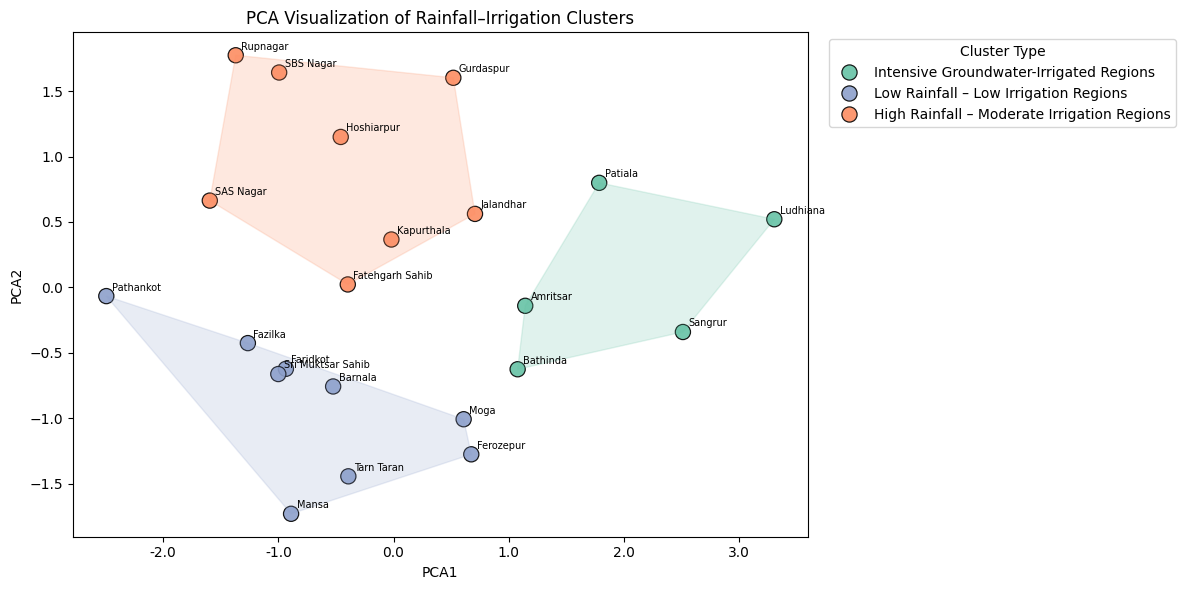

In [9]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_all_scaled)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]
print("Variance explained by 2 components:", round(pca.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(12, 6))
palette = dict(zip(cluster_names.values(), sns.color_palette('Set2', 3)))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Name', data=df, palette=palette,
                s=120, alpha=0.9, edgecolor='black')
for name in df['Cluster_Name'].unique():
    pts = df.loc[df['Cluster_Name'] == name, ['PCA1', 'PCA2']].values
    if len(pts) >= 3:
        hull = ConvexHull(pts)
        plt.fill(pts[hull.vertices, 0], pts[hull.vertices, 1], color=palette[name], alpha=0.2)
for _, r in df.iterrows():
    plt.annotate(r['District'], (r['PCA1'], r['PCA2']), fontsize=7,
                 xytext=(4, 4), textcoords='offset points')
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.title('PCA Visualization of Rainfall–Irrigation Clusters')
plt.legend(title='Cluster Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Anomaly detection with Isolation Forest

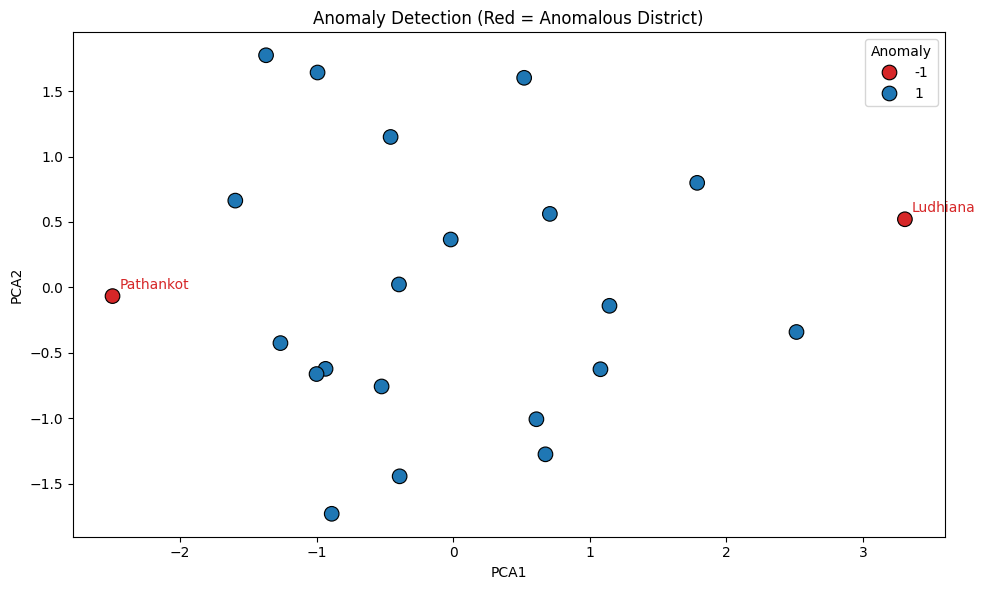

Districts with anomalous rainfall–irrigation patterns:


,District,Rainfall,Irrigation_Area,Total_Crop_Area,Avg_Crop_Yield
11,Ludhiana,555.6,279970.0,513.0,3.9
14,Pathankot,524.1,18638.2,79.0,1.9


In [10]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train_scaled)
df['Anomaly'] = iso.predict(X_all_scaled)   # 1 = normal, -1 = anomaly

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Anomaly', data=df, s=110,
                palette={1: 'tab:blue', -1: 'tab:red'}, edgecolor='black')
for _, r in df[df['Anomaly'] == -1].iterrows():
    plt.annotate(r['District'], (r['PCA1'], r['PCA2']), xytext=(5, 5),
                 textcoords='offset points', color='tab:red')
plt.title('Anomaly Detection (Red = Anomalous District)')
plt.tight_layout()
plt.show()

anomalies = df.loc[df['Anomaly'] == -1, ['District'] + features]
print("Districts with anomalous rainfall–irrigation patterns:")
anomalies.round(1)

## 9. Check any district

In [11]:
def check_district(name):
    row = df[df['District'] == name]
    if row.empty:
        return print("District not found")
    scaled = scaler.transform(row[features])
    status = "ALERT – behaves unusually compared to other districts" \
        if iso.predict(scaled)[0] == -1 else "Normal – typical rainfall–irrigation behaviour"
    print(f"District: {name}\nCluster:  {row['Cluster_Name'].iloc[0]}\nStatus:   {status}")

check_district('Ludhiana')

District: Ludhiana
Cluster:  Intensive Groundwater-Irrigated Regions
Status:   ALERT – behaves unusually compared to other districts


## 10. Key findings
- **Intensive groundwater-irrigated districts** have the largest crop area and highest yields, driven by heavy groundwater extraction rather than rainfall – a sign of long-term groundwater stress.
- **High-rainfall districts** rely less on irrigation relative to their rainfall.
- **Low-rainfall, low-irrigation districts** have smaller crop areas and lower yields.
- **Isolation Forest** flags districts whose rainfall–irrigation profile doesn't fit the usual pattern.

**Limitations:** small dataset (22 districts), single point in time, moderate cluster separation.